## Configurações e Imports

In [4]:
import warnings, os, time, pickle
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel("ERROR")

# ── Paths & Variáveis Globais ─────────────────────────────────────────
BASE_PATH   = "C:/Users/lucas/bracis/Base_DBP.xlsx"
OUT         = "/mnt/user-data/outputs"
N_TEST      = 24
N_VAL       = 12
WINDOW      = 12
WINDOW_SIZE = 12   # alias usado na abordagem Data-Centric
N_TRIALS    = 50
RANDOM_SEED = 42

os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 12, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

COLORS = {
    "main":    "#1a5276", "trend":   "#e74c3c", "season": "#27ae60",
    "resid":   "#8e44ad", "outlier": "#e74c3c", "train":  "#2c3e50",
    "test":    "#e67e22", "diff":    "#2980b9", "grid":   "#ecf0f1",
    "real":    "#2c3e50", "sarima":  "#e74c3c", "xgb":    "#27ae60",
    "lstm":    "#8e44ad", "naive":   "#95a5a6",
    "dc":      "#2980b9", "mc":      "#e67e22", "optuna": "#f39c12",
    "ok":      "#27ae60", "warn":    "#e74c3c",
}

print("✔ Ambiente configurado.")
print(f"  BASE_PATH : {BASE_PATH}")
print(f"  OUT       : {OUT}")


✔ Ambiente configurado.
  BASE_PATH : C:/Users/lucas/bracis/Base_DBP.xlsx
  OUT       : /mnt/user-data/outputs


## Etapa 1: Análise Exploratória e Decomposição

1. DATABASE — VISÃO GERAL
   Período............: 2003-08 → 2024-08
   Observações........: 253
   Frequência.........: MS (mensal, início do mês)
   Valores nulos......: 0
   Média..............: 36,156.7
   Desvio-padrão......: 21,501.7
   Mínimo.............: 8,630.0  (2004-03)
   Máximo.............: 110,107.1  (2024-05)

2. DECOMPOSIÇÃO STL (period=12)


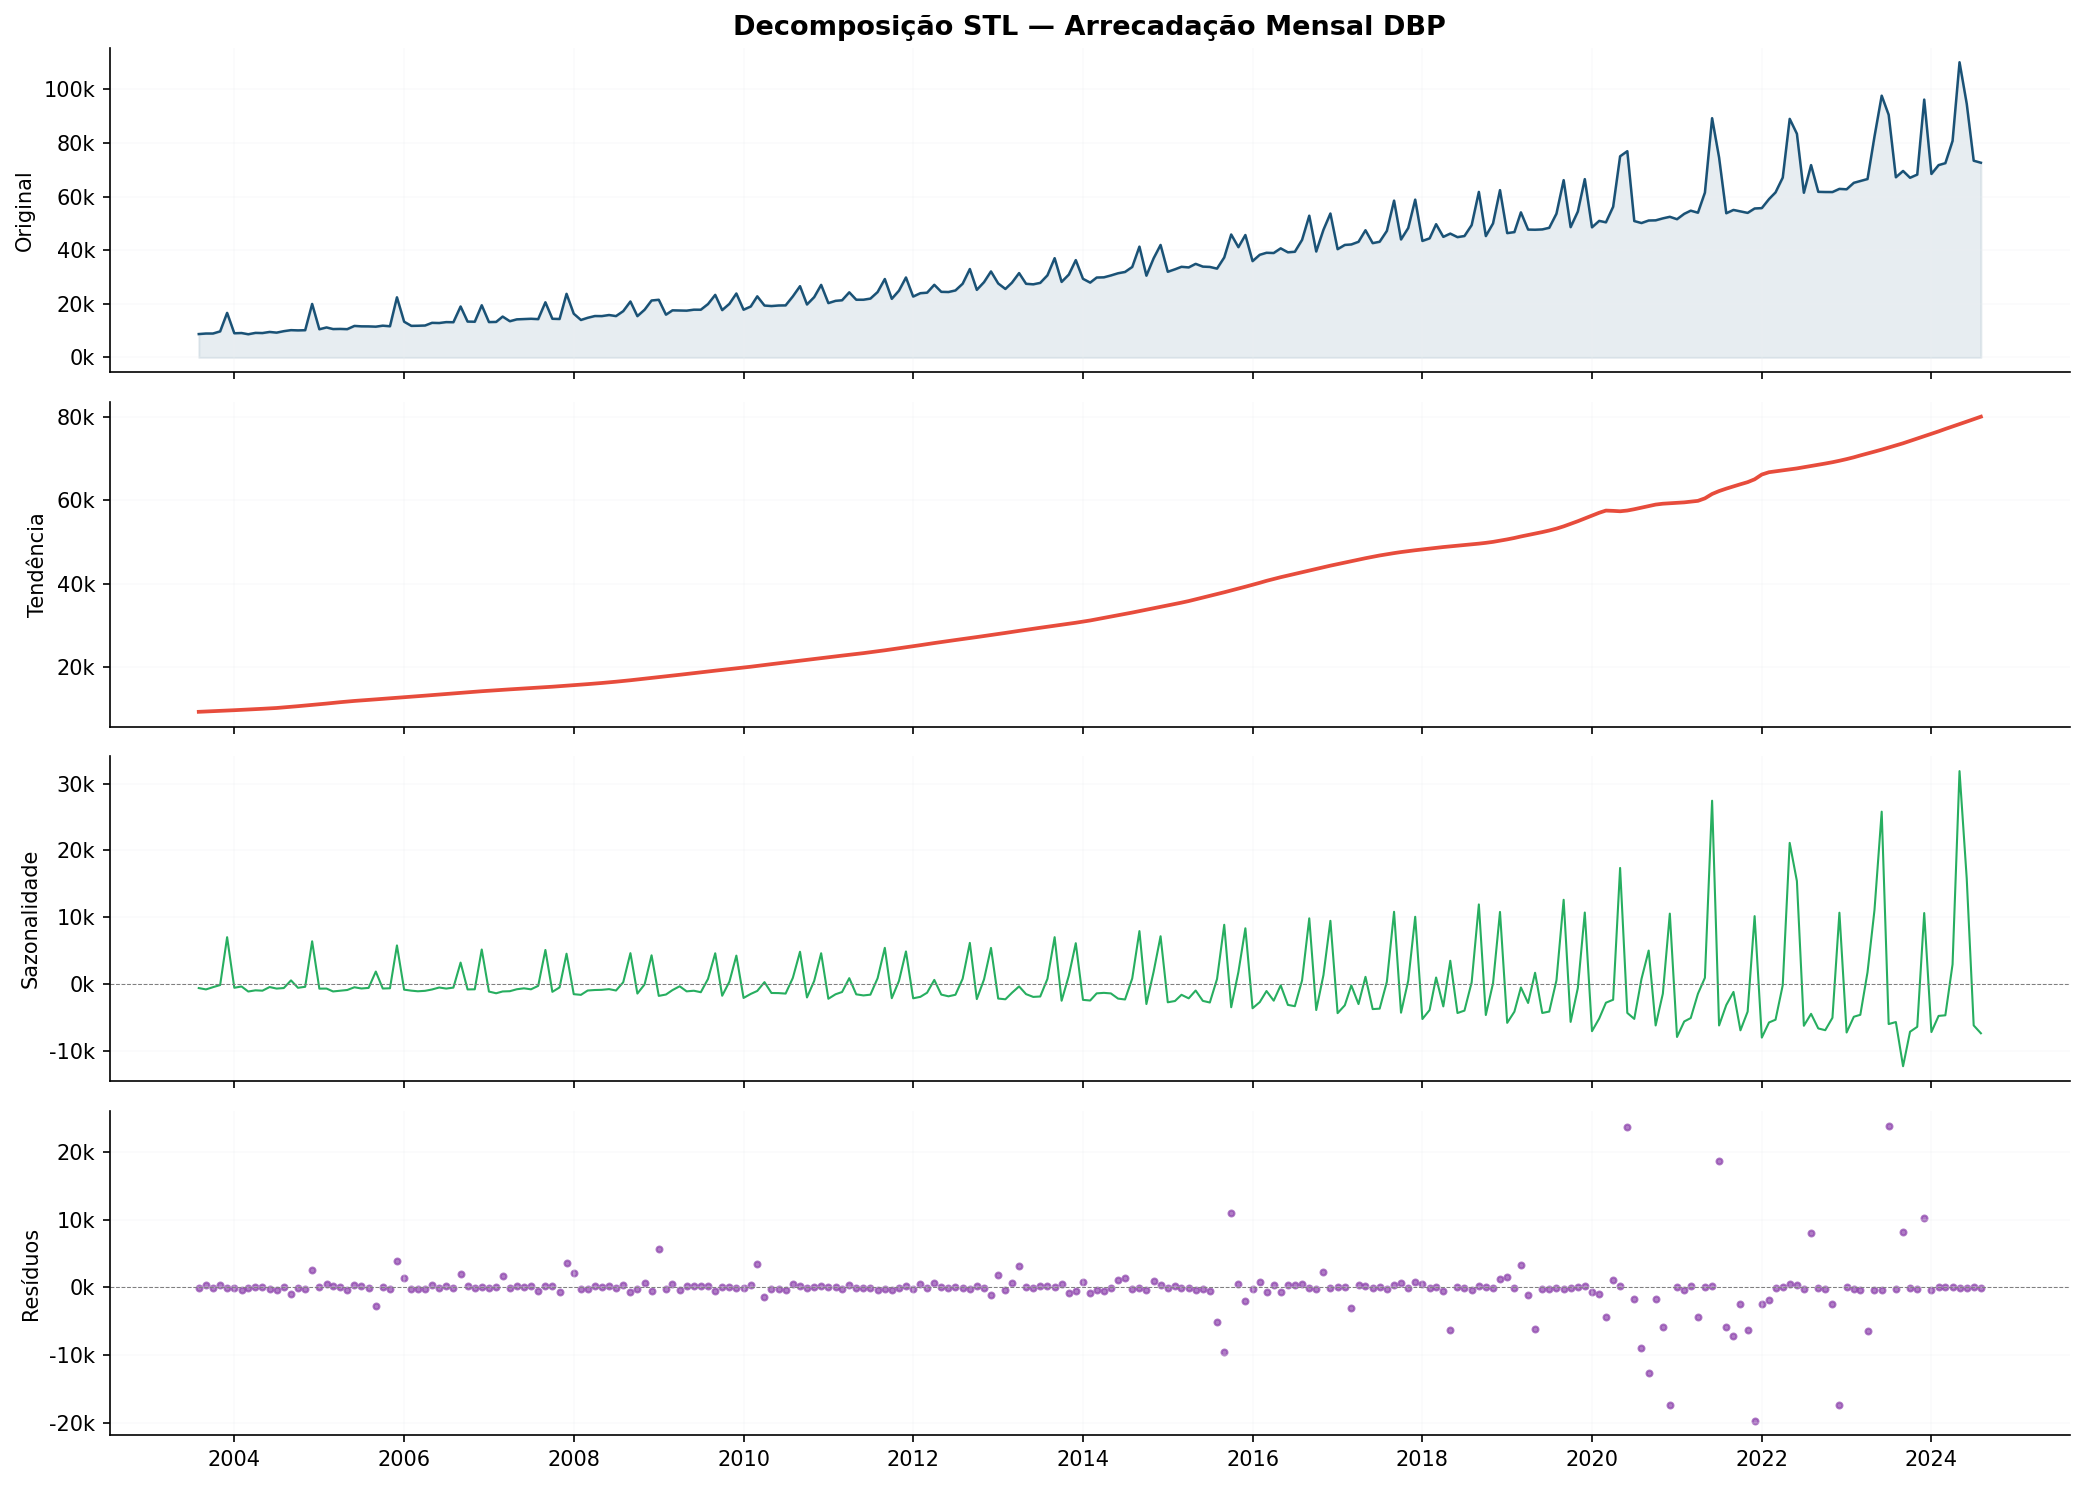

   ✔ Gráfico salvo: 01_decomposicao_stl.png
   Contribuição da sazonalidade: 26.2% do desvio total
   Contribuição da tendência...: 96.2% do desvio total

3. TESTE AUGMENTED DICKEY-FULLER

   [Série Original]
   ADF Statistic......: 3.1806
   p-value............: 1.000000
   Lags utilizados....: 16
   Valores críticos:
      1%: -3.4584  ✘
      5%: -2.8739  ✘
      10%: -2.5733  ✘
   Resultado..........: NÃO ESTACIONÁRIA ✘

   [Primeira Diferenciação]
   ADF Statistic......: -5.0950
   p-value............: 0.000014
   Lags utilizados....: 16
   Valores críticos:
      1%: -3.4585  ✔
      5%: -2.8739  ✔
      10%: -2.5734  ✔
   Resultado..........: ESTACIONÁRIA ✔

   → Série diferenciada será usada para ACF/PACF (d=1).

4. ANÁLISE DE CORRELAÇÃO (ACF & PACF)


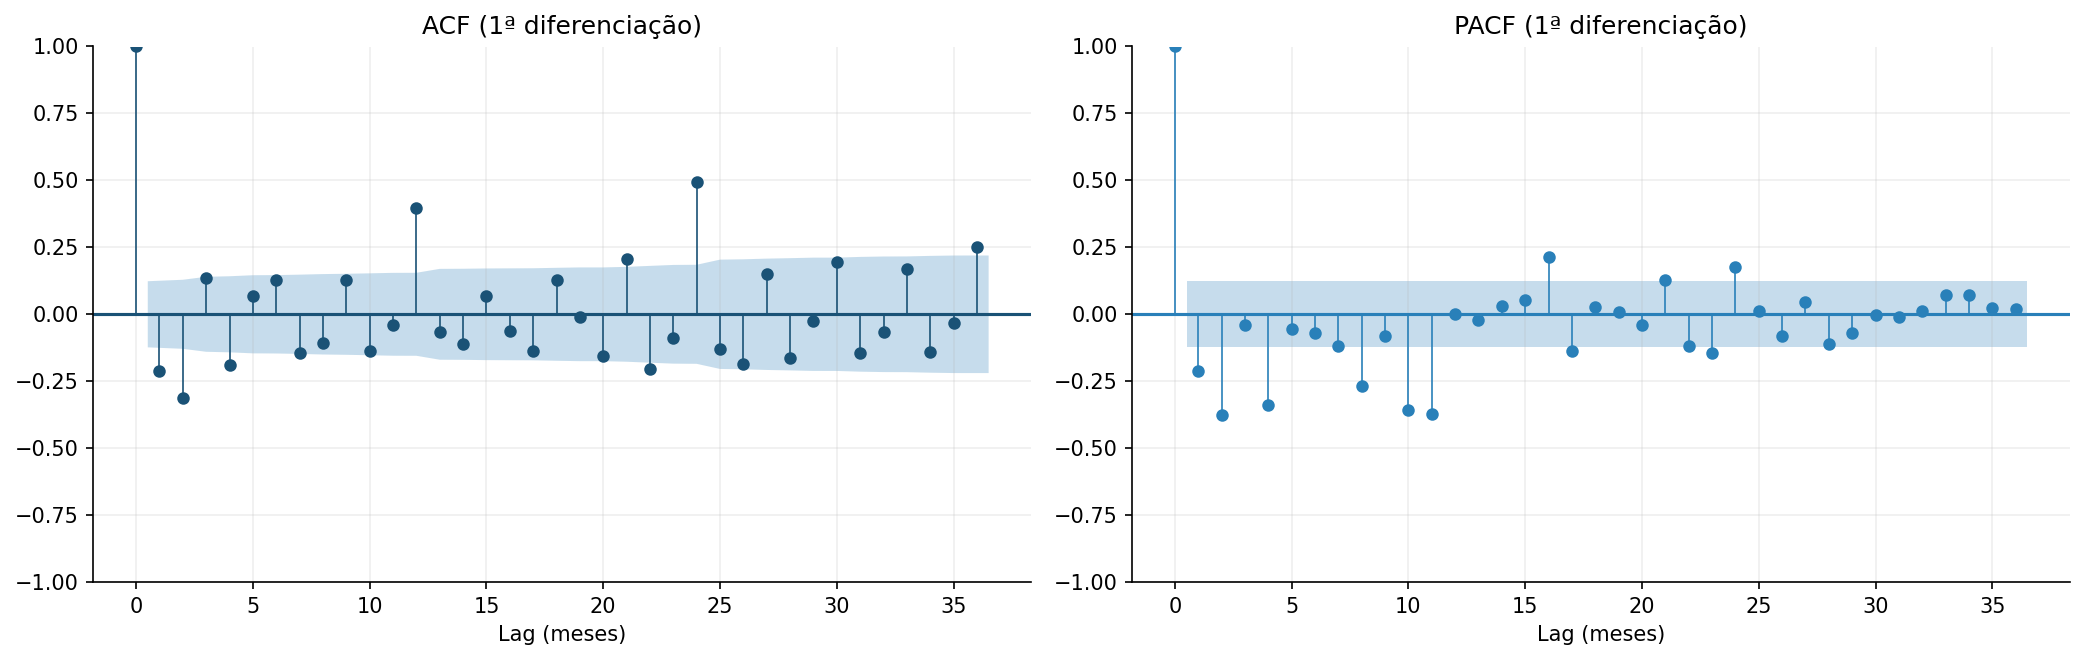

   ✔ Gráfico salvo: 02_acf_pacf.png
   Intervalo de confiança (95%): ±0.1235
   Lags ACF significativos.: [1, 2, 3, 4, 6, 7, 9, 10, 12, 17, 18, 20, 21, 22, 24]
   Lags PACF significativos: [1, 2, 4, 8, 10, 11, 16, 17, 21, 23, 24]

5. IDENTIFICAÇÃO DE PICOS (Z-SCORE ≥ 3)
   Limiar Z-score......: 3.0
   Outliers detectados.: 1

   Data                Valor    Z-score    Mês
   ──────────── ──────────── ────────── ──────
   2024-05-01     110,107.1        3.45     May


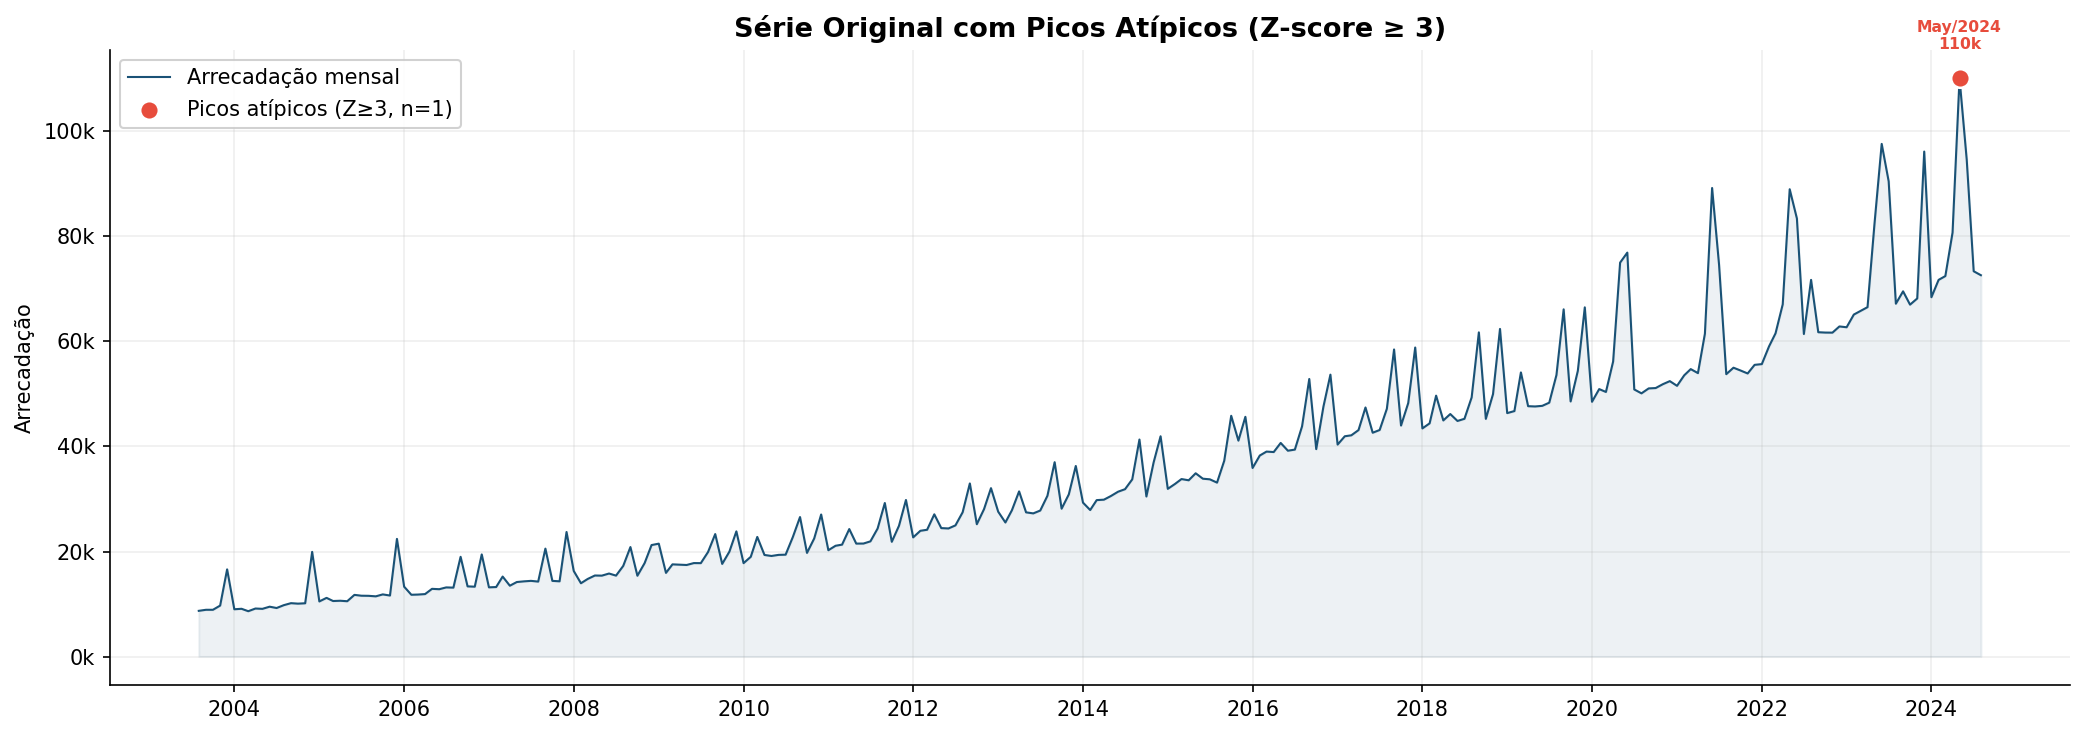


   ✔ Gráfico salvo: 03_picos_zscore.png

6. DIVISÃO CRONOLÓGICA TREINO / TESTE
   Treino: 2003-08 → 2022-08  (229 obs)
   Teste.: 2022-09 → 2024-08  (24 obs)
   Razão.: 90.5% treino / 9.5% teste


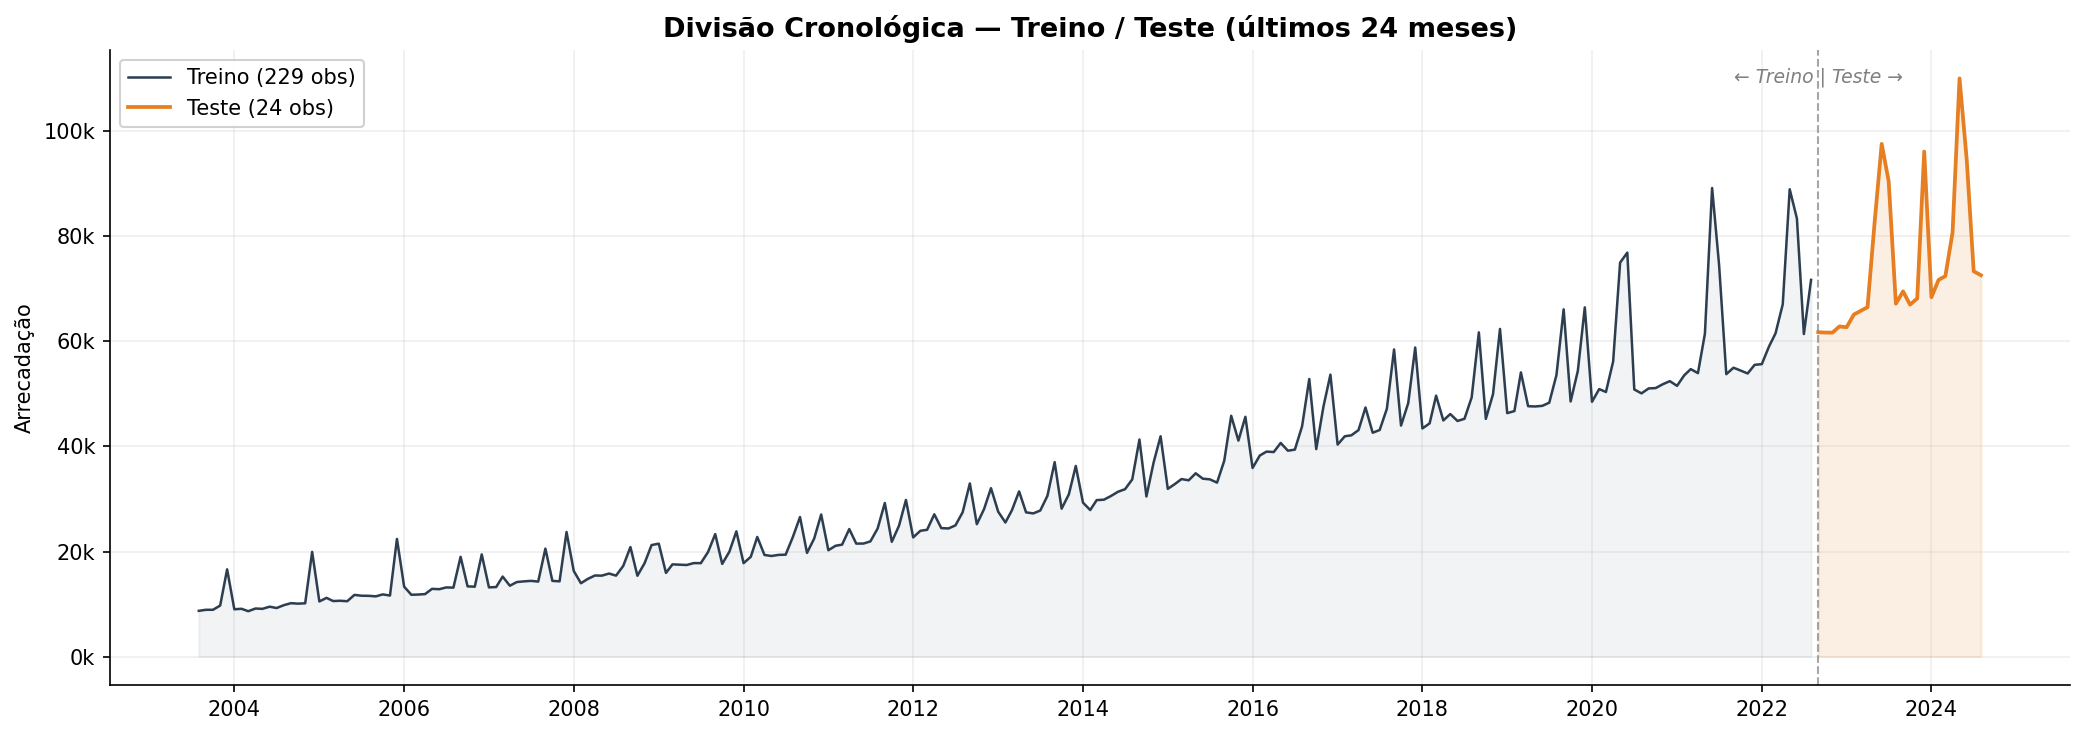

   ✔ Gráfico salvo: 04_train_test_split.png

   PIPELINE CONCLUÍDO COM SUCESSO ✔


In [5]:
# ── 1. CARGA E PREPARAÇÃO DO ÍNDICE ─────────────────────────────────────
df = pd.read_excel(BASE_PATH)
df.columns = ["data", "valores"]
df["data"] = pd.to_datetime(df["data"])
df = df.set_index("data").sort_index()
df.index = pd.DatetimeIndex([d.replace(day=1) for d in df.index], freq="MS")

ts = df["valores"].copy()
print("=" * 70)
print("1. DATABASE — VISÃO GERAL")
print("=" * 70)
print(f"   Período............: {ts.index.min():%Y-%m} → {ts.index.max():%Y-%m}")
print(f"   Observações........: {len(ts)}")
print(f"   Frequência.........: {ts.index.freqstr} (mensal, início do mês)")
print(f"   Valores nulos......: {ts.isna().sum()}")
print(f"   Média..............: {ts.mean():,.1f}")
print(f"   Desvio-padrão......: {ts.std():,.1f}")
print(f"   Mínimo.............: {ts.min():,.1f}  ({ts.idxmin():%Y-%m})")
print(f"   Máximo.............: {ts.max():,.1f}  ({ts.idxmax():%Y-%m})")

# ── 2. DECOMPOSIÇÃO STL ─────────────────────────────────────────────────
print("\n" + "=" * 70)
print("2. DECOMPOSIÇÃO STL (period=12)")
print("=" * 70)

stl = STL(ts, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ts.index, ts.values, color=COLORS["main"], lw=1.2)
axes[0].set_ylabel("Original")
axes[0].set_title("Decomposição STL — Arrecadação Mensal DBP", fontsize=13, fontweight="bold")
axes[0].fill_between(ts.index, ts.values, alpha=0.10, color=COLORS["main"])

axes[1].plot(ts.index, result.trend, color=COLORS["trend"], lw=1.8)
axes[1].set_ylabel("Tendência")

axes[2].plot(ts.index, result.seasonal, color=COLORS["season"], lw=1.0)
axes[2].axhline(0, color="grey", lw=0.5, ls="--")
axes[2].set_ylabel("Sazonalidade")

axes[3].scatter(ts.index, result.resid, color=COLORS["resid"], s=8, alpha=0.7)
axes[3].axhline(0, color="grey", lw=0.5, ls="--")
axes[3].set_ylabel("Resíduos")

for ax in axes:
    ax.grid(True, alpha=0.25, color=COLORS["grid"])
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
fig.savefig(f"{OUT}/01_decomposicao_stl.png")
plt.show() 
print("   ✔ Gráfico salvo: 01_decomposicao_stl.png")

contrib_saz = (result.seasonal.std() / ts.std()) * 100
contrib_tend = (result.trend.std() / ts.std()) * 100
print(f"   Contribuição da sazonalidade: {contrib_saz:.1f}% do desvio total")
print(f"   Contribuição da tendência...: {contrib_tend:.1f}% do desvio total")

# ── 3. TESTE ADF (ESTACIONARIDADE) ──────────────────────────────────────
print("\n" + "=" * 70)
print("3. TESTE AUGMENTED DICKEY-FULLER")
print("=" * 70)

def adf_report(series, label="Série"):
    adf_stat, p_value, used_lag, nobs, crit_vals, _ = adfuller(series.dropna(), autolag="AIC")
    estacionaria = p_value <= 0.05
    print(f"\n   [{label}]")
    print(f"   ADF Statistic......: {adf_stat:.4f}")
    print(f"   p-value............: {p_value:.6f}")
    print(f"   Lags utilizados....: {used_lag}")
    print(f"   Valores críticos:")
    for k, v in crit_vals.items():
        sinal = "✔" if adf_stat < v else "✘"
        print(f"      {k}: {v:.4f}  {sinal}")
    status = "ESTACIONÁRIA ✔" if estacionaria else "NÃO ESTACIONÁRIA ✘"
    print(f"   Resultado..........: {status}")
    return estacionaria, p_value

is_stat, pval_orig = adf_report(ts, "Série Original")

ts_diff = None
if not is_stat:
    ts_diff = ts.diff().dropna()
    is_stat_diff, pval_diff = adf_report(ts_diff, "Primeira Diferenciação")
    print(f"\n   → Série diferenciada será usada para ACF/PACF (d=1).")
else:
    print(f"\n   → Série já estacionária, nenhuma diferenciação necessária.")

# ── 4. ACF / PACF ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("4. ANÁLISE DE CORRELAÇÃO (ACF & PACF)")
print("=" * 70)

series_acf = ts_diff if ts_diff is not None else ts
diff_label = " (1ª diferenciação)" if ts_diff is not None else ""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(series_acf.dropna(), lags=36, ax=ax1, color=COLORS["main"],
         vlines_kwargs={"colors": COLORS["main"], "linewidths": 0.8},
         title=f"ACF{diff_label}")
plot_pacf(series_acf.dropna(), lags=36, ax=ax2, method="ywm",
          color=COLORS["diff"], vlines_kwargs={"colors": COLORS["diff"], "linewidths": 0.8},
          title=f"PACF{diff_label}")

for ax in (ax1, ax2):
    ax.grid(True, alpha=0.2)
    ax.set_xlabel("Lag (meses)")

plt.tight_layout()
fig.savefig(f"{OUT}/02_acf_pacf.png")
plt.show() 
print(f"   ✔ Gráfico salvo: 02_acf_pacf.png")

# Identificação de lags significativos
n = len(series_acf.dropna())
ci = 1.96 / np.sqrt(n)
from statsmodels.tsa.stattools import acf, pacf
acf_vals = acf(series_acf.dropna(), nlags=36)
pacf_vals = pacf(series_acf.dropna(), nlags=36, method="ywm")
acf_sig = [i for i in range(1, len(acf_vals)) if abs(acf_vals[i]) > ci]
pacf_sig = [i for i in range(1, len(pacf_vals)) if abs(pacf_vals[i]) > ci]
print(f"   Intervalo de confiança (95%): ±{ci:.4f}")
print(f"   Lags ACF significativos.: {acf_sig[:15]}")
print(f"   Lags PACF significativos: {pacf_sig[:15]}")

# ── 5. IDENTIFICAÇÃO DE PICOS (Z-SCORE) ─────────────────────────────────
print("\n" + "=" * 70)
print("5. IDENTIFICAÇÃO DE PICOS (Z-SCORE ≥ 3)")
print("=" * 70)

z_scores = np.abs(stats.zscore(ts.values))
z_series = pd.Series(z_scores, index=ts.index)
outlier_mask = z_scores >= 3.0
outliers = ts[outlier_mask]

print(f"   Limiar Z-score......: 3.0")
print(f"   Outliers detectados.: {outlier_mask.sum()}")
if len(outliers) > 0:
    print(f"\n   {'Data':<12} {'Valor':>12} {'Z-score':>10} {'Mês':>6}")
    print(f"   {'─'*12} {'─'*12} {'─'*10} {'─'*6}")
    for dt, val in outliers.items():
        z = z_series.loc[dt]
        month_name = dt.strftime("%b")
        print(f"   {dt:%Y-%m-%d}  {val:>12,.1f}  {z:>10.2f}  {month_name:>6}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color=COLORS["main"], lw=1.0, label="Arrecadação mensal")
ax.fill_between(ts.index, ts.values, alpha=0.08, color=COLORS["main"])

if len(outliers) > 0:
    ax.scatter(outliers.index, outliers.values, color=COLORS["outlier"],
               s=80, zorder=5, edgecolors="white", linewidths=1.2, label=f"Picos atípicos (Z≥3, n={len(outliers)})")
    for dt, val in outliers.items():
        ax.annotate(f"{dt:%b/%Y}\n{val/1000:.0f}k",
                     xy=(dt, val), xytext=(0, 14), textcoords="offset points",
                     ha="center", fontsize=7.5, fontweight="bold", color=COLORS["outlier"])

ax.set_title("Série Original com Picos Atípicos (Z-score ≥ 3)", fontsize=13, fontweight="bold")
ax.set_ylabel("Arrecadação")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/03_picos_zscore.png")
plt.show() 
print(f"\n   ✔ Gráfico salvo: 03_picos_zscore.png")

# ── 6. DIVISÃO TREINO / TESTE (ÚLTIMOS 24 MESES) ────────────────────────
print("\n" + "=" * 70)
print("6. DIVISÃO CRONOLÓGICA TREINO / TESTE")
print("=" * 70)

n_test = 24
split_point = ts.index[-n_test]
train = ts.iloc[:-n_test]
test = ts.iloc[-n_test:]

print(f"   Treino: {train.index.min():%Y-%m} → {train.index.max():%Y-%m}  ({len(train)} obs)")
print(f"   Teste.: {test.index.min():%Y-%m} → {test.index.max():%Y-%m}  ({len(test)} obs)")
print(f"   Razão.: {len(train)/len(ts)*100:.1f}% treino / {len(test)/len(ts)*100:.1f}% teste")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, color=COLORS["train"], lw=1.2, label=f"Treino ({len(train)} obs)")
ax.plot(test.index, test.values, color=COLORS["test"], lw=1.8, label=f"Teste ({len(test)} obs)")
ax.axvline(split_point, color="grey", ls="--", lw=1, alpha=0.7)
ax.annotate("← Treino | Teste →", xy=(split_point, ax.get_ylim()[1]*0.95),
            fontsize=9, ha="center", color="grey", fontstyle="italic")
ax.fill_between(train.index, train.values, alpha=0.06, color=COLORS["train"])
ax.fill_between(test.index, test.values, alpha=0.12, color=COLORS["test"])
ax.set_title("Divisão Cronológica — Treino / Teste (últimos 24 meses)", fontsize=13, fontweight="bold")
ax.set_ylabel("Arrecadação")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/04_train_test_split.png")
plt.show() 
print(f"   ✔ Gráfico salvo: 04_train_test_split.png")

print("\n" + "=" * 70)
print("   PIPELINE CONCLUÍDO COM SUCESSO ✔")
print("=" * 70)

# Aliases com nomenclatura padrão para as etapas seguintes
train_raw = train.copy()
test_raw  = test.copy()


## Etapa 2: Cenário Model-Centric (LSTM Robusta)

In [ ]:
print("=" * 70)
print("ETAPA 2 — ABORDAGEM MODEL-CENTRIC (OPTUNA)")
print("=" * 70)
print(f"   Treino: {train_raw.index.min():%Y-%m} → {train_raw.index.max():%Y-%m}  ({len(train_raw)} obs)")
print(f"   Teste.: {test_raw.index.min():%Y-%m} → {test_raw.index.max():%Y-%m}  ({len(test_raw)} obs)")
print(f"   Trials por modelo...: {N_TRIALS}")
print(f"   Validação Optuna....: últimos {N_VAL} meses do treino")
print(f"   Window size.........: {WINDOW} meses (fixo)")

# ══════════════════════════════════════════════════════════════════════
# 1. PRÉ-PROCESSAMENTO MÍNIMO — RobustScaler na série original
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("1. PRÉ-PROCESSAMENTO — RobustScaler (série original)")
print("=" * 70)

scaler_ts = RobustScaler()
train_sc_vals = scaler_ts.fit_transform(train_raw.values.reshape(-1, 1)).ravel()
test_sc_vals  = scaler_ts.transform(test_raw.values.reshape(-1, 1)).ravel()
full_sc_vals  = scaler_ts.transform(ts.values.reshape(-1, 1)).ravel()

train_sc = pd.Series(train_sc_vals, index=train_raw.index, name="scaled")
test_sc  = pd.Series(test_sc_vals,  index=test_raw.index,  name="scaled")
full_sc  = pd.Series(full_sc_vals,  index=ts.index,        name="scaled")

# Splits de treino/validação para o Optuna
train_opt = train_sc.iloc[:-N_VAL]   # treino do Optuna
val_opt   = train_sc.iloc[-N_VAL:]   # validação do Optuna

print(f"   Mediana do scaler...: {scaler_ts.center_[0]:,.2f}")
print(f"   IQR do scaler.......: {scaler_ts.scale_[0]:,.2f}")
print(f"   Treino Optuna.......: {len(train_opt)} obs")
print(f"   Validação Optuna....: {len(val_opt)} obs")

# ══════════════════════════════════════════════════════════════════════
# 2. FEATURES DE LAG (para XGBoost e LSTM)
# ══════════════════════════════════════════════════════════════════════
def make_lag_features(series, window=WINDOW):
    """Cria DataFrame com y e lag_1..lag_{window} a partir de série escalada."""
    df_f = pd.DataFrame({"y": series.values}, index=series.index)
    for i in range(1, window + 1):
        df_f[f"lag_{i}"] = series.shift(i).values
    return df_f.dropna()

full_feats = make_lag_features(full_sc)
LAG_COLS   = [c for c in full_feats.columns if c != "y"]

split_date  = test_raw.index[0]
df_tr_feat  = full_feats[full_feats.index < split_date]    # treino completo
df_te_feat  = full_feats[full_feats.index >= split_date]   # teste

# Splits dentro do treino para o Optuna
df_tr_opt  = df_tr_feat.iloc[:-N_VAL]
df_val_opt = df_tr_feat.iloc[-N_VAL:]

print(f"\n   Amostras treino (features)..: {len(df_tr_feat)}")
print(f"   Amostras teste (features)...: {len(df_te_feat)}")

# ══════════════════════════════════════════════════════════════════════
# 3A. OTIMIZAÇÃO SARIMA — Optuna
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("3A. SARIMA — Otimização Optuna (50 trials)")
print("=" * 70)

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 2)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 2)
    P = trial.suggest_int("P", 0, 1)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 1)
    try:
        fit = SARIMAX(
            train_opt,
            order=(p, d, q),
            seasonal_order=(P, D, Q, 12),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=300)
        pred = fit.forecast(steps=N_VAL).values
        return float(np.sqrt(mean_squared_error(val_opt.values, pred)))
    except Exception:
        return float("inf")

t0 = time.time()
sarima_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
sarima_study.optimize(sarima_objective, n_trials=N_TRIALS, show_progress_bar=False)
sarima_search_time = time.time() - t0

best_sarima = sarima_study.best_params
print(f"   Melhor RMSE (val)...: {sarima_study.best_value:.6f}")
print(f"   Parâmetros ótimos...: order=({best_sarima['p']},{best_sarima['d']},{best_sarima['q']})  "
      f"seasonal=({best_sarima['P']},{best_sarima['D']},{best_sarima['Q']},12)")
print(f"   Tempo de busca......: {sarima_search_time:.1f}s")

# Treino final com todos os dados de treino
print("   → Treino final com melhores parâmetros...")
t0 = time.time()
sarima_final = SARIMAX(
    train_sc,
    order=(best_sarima["p"], best_sarima["d"], best_sarima["q"]),
    seasonal_order=(best_sarima["P"], best_sarima["D"], best_sarima["Q"], 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=500)
sarima_train_time = time.time() - t0

sarima_pred_sc = sarima_final.forecast(steps=N_TEST)
sarima_pred = pd.Series(
    scaler_ts.inverse_transform(sarima_pred_sc.values.reshape(-1, 1)).ravel(),
    index=test_raw.index, name="SARIMA"
)
print(f"   Tempo treino final..: {sarima_train_time:.1f}s")
conv = sarima_final.mle_retvals.get("converged", False)
print(f"   Convergência........: {'Sim ✔' if conv else 'Não ✘'}")
print(f"   AIC.................: {sarima_final.aic:,.1f}")

# ══════════════════════════════════════════════════════════════════════
# 3B. OTIMIZAÇÃO XGBOOST — Optuna
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("3B. XGBoost — Otimização Optuna (50 trials)")
print("=" * 70)

def xgb_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth":     trial.suggest_int("max_depth", 3, 10),
        "subsample":     trial.suggest_float("subsample", 0.5, 1.0),
        "n_estimators":  trial.suggest_int("n_estimators", 100, 500),
        "random_state":  42,
        "verbosity":     0,
    }
    m = xgb.XGBRegressor(**params)
    m.fit(df_tr_opt[LAG_COLS], df_tr_opt["y"])
    pred = m.predict(df_val_opt[LAG_COLS])
    return float(np.sqrt(mean_squared_error(df_val_opt["y"].values, pred)))

t0 = time.time()
xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
xgb_search_time = time.time() - t0

best_xgb = xgb_study.best_params
print(f"   Melhor RMSE (val)...: {xgb_study.best_value:.6f}")
print(f"   learning_rate.......: {best_xgb['learning_rate']:.5f}")
print(f"   max_depth...........: {best_xgb['max_depth']}")
print(f"   subsample...........: {best_xgb['subsample']:.4f}")
print(f"   n_estimators........: {best_xgb['n_estimators']}")
print(f"   Tempo de busca......: {xgb_search_time:.1f}s")

print("   → Treino final com melhores parâmetros...")
t0 = time.time()
xgb_final = xgb.XGBRegressor(**{**best_xgb, "random_state": 42, "verbosity": 0})
xgb_final.fit(df_tr_feat[LAG_COLS], df_tr_feat["y"])
xgb_train_time = time.time() - t0

xgb_pred_sc = xgb_final.predict(df_te_feat[LAG_COLS])
xgb_pred = pd.Series(
    scaler_ts.inverse_transform(xgb_pred_sc.reshape(-1, 1)).ravel(),
    index=df_te_feat.index, name="XGBoost"
)
print(f"   Tempo treino final..: {xgb_train_time:.2f}s")

# ══════════════════════════════════════════════════════════════════════
# 3C. OTIMIZAÇÃO LSTM — Optuna
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("3C. LSTM — Otimização Optuna (50 trials)")
print("=" * 70)

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def to_lstm_3d(X_arr):
    """Converte array 2D (samples, lags) para 3D (samples, timesteps, 1)."""
    return X_arr.reshape(-1, WINDOW, 1).astype(np.float32)

X_tr_opt_3d = to_lstm_3d(df_tr_opt[LAG_COLS].values)
y_tr_opt    = df_tr_opt["y"].values.astype(np.float32)
X_val_3d    = to_lstm_3d(df_val_opt[LAG_COLS].values)
y_val       = df_val_opt["y"].values.astype(np.float32)

def lstm_objective(trial):
    units   = trial.suggest_int("units", 32, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr      = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    tf.random.set_seed(42)
    np.random.seed(42)
    model = Sequential([
        LSTM(units, input_shape=(WINDOW, 1)),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    cb = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)
    model.fit(
        X_tr_opt_3d, y_tr_opt,
        epochs=100, batch_size=16,
        validation_data=(X_val_3d, y_val),
        callbacks=[cb], verbose=0,
    )
    pred = model.predict(X_val_3d, verbose=0).ravel()
    rmse = float(np.sqrt(mean_squared_error(y_val, pred)))
    del model
    tf.keras.backend.clear_session()
    return rmse

t0 = time.time()
lstm_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
lstm_study.optimize(lstm_objective, n_trials=N_TRIALS, show_progress_bar=False)
lstm_search_time = time.time() - t0

best_lstm = lstm_study.best_params
print(f"   Melhor RMSE (val)...: {lstm_study.best_value:.6f}")
print(f"   units...............: {best_lstm['units']}")
print(f"   dropout.............: {best_lstm['dropout']:.4f}")
print(f"   learning_rate.......: {best_lstm['learning_rate']:.6f}")
print(f"   Tempo de busca......: {lstm_search_time:.1f}s")

print("   → Treino final com melhores parâmetros (todos os dados de treino)...")
X_tr_full_3d = to_lstm_3d(df_tr_feat[LAG_COLS].values)
y_tr_full    = df_tr_feat["y"].values.astype(np.float32)
X_te_3d      = to_lstm_3d(df_te_feat[LAG_COLS].values)

tf.random.set_seed(42)
np.random.seed(42)
t0 = time.time()
lstm_final = Sequential([
    LSTM(best_lstm["units"], input_shape=(WINDOW, 1)),
    Dropout(best_lstm["dropout"]),
    Dense(1),
])
lstm_final.compile(optimizer=Adam(learning_rate=best_lstm["learning_rate"]), loss="mse")
es_final = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0)
hist_final = lstm_final.fit(
    X_tr_full_3d, y_tr_full,
    epochs=200, batch_size=16,
    validation_split=0.15,
    callbacks=[es_final], verbose=0,
)
lstm_train_time = time.time() - t0

lstm_pred_sc = lstm_final.predict(X_te_3d, verbose=0).ravel()
lstm_pred = pd.Series(
    scaler_ts.inverse_transform(lstm_pred_sc.reshape(-1, 1)).ravel(),
    index=df_te_feat.index, name="LSTM"
)
epochs_run = len(hist_final.history["loss"])
best_epoch = int(np.argmin(hist_final.history["val_loss"])) + 1
print(f"   Épocas executadas...: {epochs_run} (melhor: {best_epoch})")
print(f"   Tempo treino final..: {lstm_train_time:.1f}s")

# ══════════════════════════════════════════════════════════════════════
# 4. RESUMO TEMPORAL DA OTIMIZAÇÃO
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("4. RESUMO DOS TEMPOS — Model-Centric")
print("=" * 70)
print(f"\n   {'Modelo':<12} {'Search Time (s)':>16} {'Train Final (s)':>16} {'Total (s)':>12}")
print(f"   {'-'*12} {'-'*16} {'-'*16} {'-'*12}")
for name, st, tt in [
    ("SARIMA",  sarima_search_time, sarima_train_time),
    ("XGBoost", xgb_search_time,    xgb_train_time),
    ("LSTM",    lstm_search_time,    lstm_train_time),
]:
    print(f"   {name:<12} {st:>16.1f} {tt:>16.1f} {st+tt:>12.1f}")

# ══════════════════════════════════════════════════════════════════════
# 5. ARMAZENAMENTO — Previsões, Parâmetros e Tempos
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("5. ARMAZENAMENTO DE ARTEFATOS")
print("=" * 70)

common_idx = (sarima_pred.index
              .intersection(xgb_pred.index)
              .intersection(lstm_pred.index))

results3 = pd.DataFrame({
    "Real":    test_raw.loc[common_idx],
    "SARIMA":  sarima_pred.loc[common_idx],
    "XGBoost": xgb_pred.loc[common_idx],
    "LSTM":    lstm_pred.loc[common_idx],
}, index=common_idx)

best_params = {
    "SARIMA":  best_sarima,
    "XGBoost": best_xgb,
    "LSTM":    best_lstm,
}

search_times = {
    "SARIMA":  sarima_search_time,
    "XGBoost": xgb_search_time,
    "LSTM":    lstm_search_time,
}

train_times = {
    "SARIMA":  sarima_train_time,
    "XGBoost": xgb_train_time,
    "LSTM":    lstm_train_time,
}

artifacts3 = {
    "train_raw":    train_raw,
    "test_raw":     test_raw,
    "scaler_ts":    scaler_ts,
    "results":      results3,
    "sarima_pred":  sarima_pred,
    "xgb_pred":     xgb_pred,
    "lstm_pred":    lstm_pred,
    "best_params":  best_params,
    "search_times": search_times,
    "train_times":  train_times,
    "sarima_final": sarima_final,
    "xgb_final":    xgb_final,
    "sarima_study": sarima_study,
    "xgb_study":    xgb_study,
    "lstm_study":   lstm_study,
    "WINDOW_SIZE":  WINDOW,
    "N_TRIALS":     N_TRIALS,
    "LAG_COLS":     LAG_COLS,
}

lstm_final.save(f"{OUT}/mc_lstm_model.keras")
print(f"   Modelo LSTM salvo: mc_lstm_model.keras")

with open(f"{OUT}/mc_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts3, f)
print(f"   Artefatos salvos.: mc_artifacts.pkl")

with open(f"{OUT}/mc_best_params.txt", "w", encoding="utf-8") as f:
    f.write("ETAPA 3 — Model-Centric — Melhores Parâmetros Optuna\n")
    f.write("=" * 55 + "\n\n")
    for model_name, params in best_params.items():
        f.write(f"{model_name}:\n")
        for k, v in params.items():
            f.write(f"   {k}: {v}\n")
        f.write(f"   [search_time]: {search_times[model_name]:.1f}s\n\n")
print(f"   Parâmetros salvos: mc_best_params.txt")

# ══════════════════════════════════════════════════════════════════════
# 6. VISUALIZAÇÕES
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("6. VISUALIZAÇÕES")
print("=" * 70)

# --- 6a. Previsões vs Real ---
fig, ax = plt.subplots(figsize=(14, 5.5))
ctx = train_raw.iloc[-36:]
ax.plot(ctx.index, ctx.values, color=COLORS["train"], lw=1.0, ls="--", alpha=0.6, label="Treino (contexto)")
ax.plot(results3.index, results3["Real"],    color=COLORS["real"],   lw=2.0, marker="o", ms=4, label="Real")
ax.plot(results3.index, results3["SARIMA"],  color=COLORS["sarima"], lw=1.5, marker="s", ms=3,
        label=f"SARIMA ({sarima_search_time:.0f}s busca)", alpha=0.85)
ax.plot(results3.index, results3["XGBoost"], color=COLORS["xgb"],   lw=1.5, marker="^", ms=3,
        label=f"XGBoost ({xgb_search_time:.0f}s busca)", alpha=0.85)
ax.plot(results3.index, results3["LSTM"],    color=COLORS["lstm"],  lw=1.5, marker="d", ms=3,
        label=f"LSTM ({lstm_search_time:.0f}s busca)", alpha=0.85)
ax.axvline(test_raw.index[0], color="grey", ls=":", lw=0.8, alpha=0.5)
ax.set_title("Etapa 3 — Previsões Model-Centric (Optuna) vs Real", fontsize=13, fontweight="bold")
ax.set_ylabel("Arrecadação")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
plt.xticks(rotation=45, ha="right")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/08_previsoes_etapa3.png")
plt.show()
print("   ✔ Gráfico salvo: 08_previsoes_etapa3.png")

# --- 6b. Histórico de otimização Optuna ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
studies = [sarima_study, xgb_study,    lstm_study]
names   = ["SARIMA",     "XGBoost",    "LSTM"]
palette = [COLORS["sarima"], COLORS["xgb"], COLORS["lstm"]]

for ax, study, name, color in zip(axes, studies, names, palette):
    vals  = [t.value for t in study.trials if t.value is not None and t.value < float("inf")]
    best_ = np.minimum.accumulate(vals)
    ax.scatter(range(len(vals)), vals, color=color, s=15, alpha=0.4, label="Trial RMSE")
    ax.plot(range(len(best_)), best_, color="black", lw=1.5, label="Melhor acumulado")
    ax.set_title(f"{name}\nMelhor RMSE={best_[-1]:.4f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Trial")
    ax.set_ylabel("RMSE (escala norm.)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle("Etapa 3 — Histórico de Otimização Optuna (50 trials)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(f"{OUT}/09_optuna_historico.png")
plt.show()
print("   ✔ Gráfico salvo: 09_optuna_historico.png")

# --- 6c. Comparação de tempos de busca ---
fig, ax = plt.subplots(figsize=(8, 4))
model_names = ["SARIMA", "XGBoost", "LSTM"]
s_times = [sarima_search_time, xgb_search_time, lstm_search_time]
t_times = [sarima_train_time,  xgb_train_time,  lstm_train_time]
x = np.arange(len(model_names))
w = 0.35

bars1 = ax.bar(x - w/2, s_times, w, label="Search Time (Optuna)",
               color=[COLORS["sarima"], COLORS["xgb"], COLORS["lstm"]], alpha=0.85)
bars2 = ax.bar(x + w/2, t_times, w, label="Train Final",
               color=[COLORS["sarima"], COLORS["xgb"], COLORS["lstm"]], alpha=0.45,
               edgecolor="grey", lw=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f}s", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("Tempo (s)")
ax.set_title("Etapa 3 — Tempo de Busca vs Treino Final", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/10_tempos_etapa3.png")
plt.show()
print("   ✔ Gráfico salvo: 10_tempos_etapa3.png")

# --- 6d. Tabela final de previsões ---
print(f"\n   PREVISÕES MENSAIS (escala original):")
print(f"   {'Mês':<10} {'Real':>10} {'SARIMA':>10} {'XGBoost':>10} {'LSTM':>10}")
print(f"   {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
for dt in results3.index:
    r = results3.loc[dt]
    print(f"   {dt:%Y-%m}   {r['Real']:>10,.0f} {r['SARIMA']:>10,.0f} {r['XGBoost']:>10,.0f} {r['LSTM']:>10,.0f}")

print("\n" + "=" * 70)
print("   ETAPA 3 CONCLUÍDA COM SUCESSO ✔")
print("=" * 70)


ETAPA 2 — ABORDAGEM MODEL-CENTRIC (OPTUNA)
   Treino: 2003-08 → 2022-08  (229 obs)
   Teste.: 2022-09 → 2024-08  (24 obs)
   Trials por modelo...: 50
   Validação Optuna....: últimos 12 meses do treino
   Window size.........: 12 meses (fixo)

1. PRÉ-PROCESSAMENTO — RobustScaler (série original)
   Mediana do scaler...: 27,898.60
   IQR do scaler.......: 28,749.10
   Treino Optuna.......: 217 obs
   Validação Optuna....: 12 obs

   Amostras treino (features)..: 217
   Amostras teste (features)...: 24

3A. SARIMA — Otimização Optuna (50 trials)
   Melhor RMSE (val)...: 0.280369
   Parâmetros ótimos...: order=(1,0,2)  seasonal=(1,0,1,12)
   Tempo de busca......: 51.0s
   → Treino final com melhores parâmetros...
   Tempo treino final..: 0.5s
   Convergência........: Sim ✔
   AIC.................: -196.5

3B. XGBoost — Otimização Optuna (50 trials)
   Melhor RMSE (val)...: 0.282080
   learning_rate.......: 0.01463
   max_depth...........: 3
   subsample...........: 0.5792
   n_estimators.

## Etapa 3: Cenário Data-Centric (Engenharia de Features + LSTM Simples)

In [ ]:
print("=" * 70)
print("ETAPA 3 — ABORDAGEM DATA-CENTRIC")
print("=" * 70)
print(f"   Treino: {train_raw.index.min():%Y-%m} → {train_raw.index.max():%Y-%m}  ({len(train_raw)} obs)")
print(f"   Teste.: {test_raw.index.min():%Y-%m} → {test_raw.index.max():%Y-%m}  ({len(test_raw)} obs)")

# ══════════════════════════════════════════════════════════════════════
# 1. TRANSFORMAÇÃO BOX-COX
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("1. TRANSFORMAÇÃO BOX-COX")
print("=" * 70)

train_bc, lam = boxcox(train_raw.values)
train_bc = pd.Series(train_bc, index=train_raw.index, name="valores_bc")

# Transformar o teste com o MESMO lambda (sem data leakage)
test_bc_vals = boxcox(test_raw.values, lmbda=lam)
test_bc = pd.Series(test_bc_vals, index=test_raw.index, name="valores_bc")

# Série completa transformada (para feature engineering)
full_bc_vals = boxcox(ts.values, lmbda=lam)
full_bc = pd.Series(full_bc_vals, index=ts.index, name="valores_bc")

print(f"   Lambda ótimo........: {lam:.6f}")
print(f"   Interpretação.......: {'~log' if abs(lam) < 0.05 else '~raiz quadrada' if abs(lam - 0.5) < 0.1 else f'potência {lam:.2f}'}")
print(f"   Variância original..: {train_raw.var():,.1f}")
print(f"   Variância Box-Cox...: {train_bc.var():,.4f}")
print(f"   Redução de variância: {(1 - train_bc.var()/train_raw.var())*100:.1f}%")

# ══════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("2. FEATURE ENGINEERING")
print("=" * 70)


def create_features(series, window_size=WINDOW_SIZE):
    """
    Gera features a partir de uma série Box-Cox transformada:
      - 12 lags (t-1 a t-12)
      - Diferenciação sazonal (valor - lag_12)
      - Média móvel de 3 meses
      - Média móvel de 12 meses
    """
    df_feat = pd.DataFrame(index=series.index)
    df_feat["y"] = series.values

    # 12 Lags
    for i in range(1, window_size + 1):
        df_feat[f"lag_{i}"] = series.shift(i).values

    # Diferenciação sazonal (t - t-12)
    df_feat["diff_saz_12"] = series.values - series.shift(12).values

    # Médias móveis
    df_feat["ma_3"]  = series.rolling(window=3).mean().values
    df_feat["ma_12"] = series.rolling(window=12).mean().values

    return df_feat

# Criar features sobre a série COMPLETA transformada
df_features = create_features(full_bc)
feature_cols = [c for c in df_features.columns if c != "y"]

print(f"   Features criadas....: {len(feature_cols)}")
print(f"   Lista...............: {feature_cols[:6]} ... {feature_cols[-3:]}")
print(f"   Window size.........: {WINDOW_SIZE} meses")

# Separar treino/teste respeitando o split cronológico
split_date = test_raw.index[0]
df_train_feat = df_features.loc[df_features.index < split_date].dropna()
df_test_feat  = df_features.loc[df_features.index >= split_date].dropna()

print(f"   Amostras treino.....: {len(df_train_feat)} (após remoção de NaN por lags)")
print(f"   Amostras teste......: {len(df_test_feat)}")

# ══════════════════════════════════════════════════════════════════════
# 3. NORMALIZAÇÃO COM ROBUSTSCALER
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("3. NORMALIZAÇÃO (RobustScaler)")
print("=" * 70)

scaler_X = RobustScaler()
scaler_y = RobustScaler()

X_train = scaler_X.fit_transform(df_train_feat[feature_cols])
X_test  = scaler_X.transform(df_test_feat[feature_cols])

y_train_scaled = scaler_y.fit_transform(df_train_feat[["y"]])
y_test_scaled  = scaler_y.transform(df_test_feat[["y"]])

print(f"   Scaler X fitado em..: {X_train.shape[0]} amostras × {X_train.shape[1]} features")
print(f"   Mediana features....: [{', '.join(f'{v:.2f}' for v in scaler_X.center_[:4])} ...]")
print(f"   IQR features........: [{', '.join(f'{v:.2f}' for v in scaler_X.scale_[:4])} ...]")
print(f"   Scaler y (mediana)..: {scaler_y.center_[0]:.4f}")
print(f"   Scaler y (IQR)......: {scaler_y.scale_[0]:.4f}")

# ══════════════════════════════════════════════════════════════════════
# 4A. MODELO SARIMA (1,1,1)(1,1,1,12)
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("4A. SARIMA(1,1,1)(1,1,1,12) — Série Box-Cox")
print("=" * 70)

t0 = time.time()
sarima_model = SARIMAX(
    train_bc,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False, maxiter=500)
sarima_time = time.time() - t0

# Previsão no espaço Box-Cox → inversão para escala original
sarima_pred_bc = sarima_fit.forecast(steps=N_TEST)
sarima_pred = pd.Series(
    inv_boxcox(sarima_pred_bc.values, lam),
    index=test_raw.index,
    name="SARIMA"
)

print(f"   Convergência........: {'Sim ✔' if sarima_fit.mle_retvals['converged'] else 'Não ✘'}")
print(f"   AIC.................: {sarima_fit.aic:,.1f}")
print(f"   BIC.................: {sarima_fit.bic:,.1f}")
print(f"   Tempo de treino.....: {sarima_time:.2f}s")

# ══════════════════════════════════════════════════════════════════════
# 4B. MODELO XGBOOST (vanilla)
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("4B. XGBoost (n=100, depth=3, lr=0.1)")
print("=" * 70)

t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0,
)
xgb_model.fit(X_train, y_train_scaled.ravel())
xgb_time = time.time() - t0

# Previsão: desescalar → inverter Box-Cox
xgb_pred_scaled = xgb_model.predict(X_test)
xgb_pred_bc = scaler_y.inverse_transform(xgb_pred_scaled.reshape(-1, 1)).ravel()
xgb_pred = pd.Series(
    inv_boxcox(xgb_pred_bc, lam),
    index=df_test_feat.index,
    name="XGBoost"
)

print(f"   Árvores.............: {xgb_model.n_estimators}")
print(f"   Profundidade........: {xgb_model.max_depth}")
print(f"   Learning rate.......: {xgb_model.learning_rate}")
print(f"   Tempo de treino.....: {xgb_time:.2f}s")

# ══════════════════════════════════════════════════════════════════════
# 4C. MODELO LSTM (50 neurônios, dropout 0.2, EarlyStopping)
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("4C. LSTM (50 units, dropout=0.2, EarlyStopping)")
print("=" * 70)

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reshape para LSTM: (samples, timesteps=WINDOW_SIZE, features_per_step)
# Usar os 12 lags como a sequência temporal; demais features replicadas
n_lag_feats = WINDOW_SIZE  # lag_1..lag_12
n_extra = len(feature_cols) - n_lag_feats  # diff_saz_12, ma_3, ma_12

def reshape_for_lstm(X, n_lags=WINDOW_SIZE):
    """
    Reorganiza features para input 3D do LSTM.
    Lags viram timesteps; features extras são replicadas em cada timestep.
    Shape final: (samples, n_lags, 1 + n_extra_features)
    """
    lag_cols = X[:, :n_lags]         # primeiras 12 cols = lags
    extra_cols = X[:, n_lags:]       # diff_saz, ma_3, ma_12

    # Cada timestep: lag_value + extras replicadas
    sequences = []
    for i in range(X.shape[0]):
        step_data = []
        for t in range(n_lags):
            row = [lag_cols[i, t]] + list(extra_cols[i])
            step_data.append(row)
        sequences.append(step_data)

    return np.array(sequences, dtype=np.float32)

X_train_lstm = reshape_for_lstm(X_train)
X_test_lstm  = reshape_for_lstm(X_test)

n_features_per_step = 1 + n_extra
print(f"   Shape treino........: {X_train_lstm.shape} (samples, timesteps, features)")
print(f"   Shape teste.........: {X_test_lstm.shape}")

tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(50, input_shape=(WINDOW_SIZE, n_features_per_step), return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=0,
)

t0 = time.time()
history = lstm_model.fit(
    X_train_lstm, y_train_scaled,
    epochs=200,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0,
)
lstm_time = time.time() - t0

# Previsão
lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred_bc = scaler_y.inverse_transform(lstm_pred_scaled).ravel()
lstm_pred = pd.Series(
    inv_boxcox(lstm_pred_bc, lam),
    index=df_test_feat.index,
    name="LSTM"
)

epochs_run = len(history.history["loss"])
best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"   Épocas executadas...: {epochs_run} (melhor: {best_epoch})")
print(f"   Val loss final......: {history.history['val_loss'][-1]:.6f}")
print(f"   Val loss melhor.....: {min(history.history['val_loss']):.6f}")
print(f"   Tempo de treino.....: {lstm_time:.2f}s")

# ══════════════════════════════════════════════════════════════════════
# 5. RESUMO E ARMAZENAMENTO
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("5. RESUMO DA ETAPA 2")
print("=" * 70)

# Alinhar índices (todos devem ter as mesmas datas)
common_idx = sarima_pred.index.intersection(xgb_pred.index).intersection(lstm_pred.index)
results = pd.DataFrame({
    "Real":    test_raw.loc[common_idx],
    "SARIMA":  sarima_pred.loc[common_idx],
    "XGBoost": xgb_pred.loc[common_idx],
    "LSTM":    lstm_pred.loc[common_idx],
}, index=common_idx)

print(f"\n   {'Modelo':<12} {'Tempo (s)':>10} {'Previsões':>10}")
print(f"   {'─'*12} {'─'*10} {'─'*10}")
print(f"   {'SARIMA':<12} {sarima_time:>10.2f} {len(sarima_pred):>10}")
print(f"   {'XGBoost':<12} {xgb_time:>10.2f} {len(xgb_pred):>10}")
print(f"   {'LSTM':<12} {lstm_time:>10.2f} {len(lstm_pred):>10}")

# Salvar artefatos para etapas futuras
artifacts = {
    "lambda": lam,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "feature_cols": feature_cols,
    "train_raw": train_raw,
    "test_raw": test_raw,
    "train_bc": train_bc,
    "test_bc": test_bc,
    "full_bc": full_bc,
    "results": results,
    "sarima_fit": sarima_fit,
    "xgb_model": xgb_model,
    "lstm_model": lstm_model,
    "sarima_pred": sarima_pred,
    "xgb_pred": xgb_pred,
    "lstm_pred": lstm_pred,
    "sarima_time": sarima_time,
    "xgb_time": xgb_time,
    "lstm_time": lstm_time,
    "history": history.history,
    "df_features": df_features,
    "WINDOW_SIZE": WINDOW_SIZE,
}
with open(f"{OUT}/dc_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)
print(f"\n   ✔ Artefatos salvos: dc_artifacts.pkl")

# ══════════════════════════════════════════════════════════════════════
# 6. VISUALIZAÇÕES
# ══════════════════════════════════════════════════════════════════════

# --- 6a. Previsões vs Real ---
fig, ax = plt.subplots(figsize=(14, 5.5))

# Contexto: últimos 36 meses do treino
ctx = train_raw.iloc[-36:]
ax.plot(ctx.index, ctx.values, color=COLORS["train"], lw=1.0, ls="--", alpha=0.6, label="Treino (contexto)")

ax.plot(results.index, results["Real"],    color=COLORS["real"],   lw=2.0, marker="o", ms=4, label="Real")
ax.plot(results.index, results["SARIMA"],  color=COLORS["sarima"], lw=1.5, marker="s", ms=3, label=f"SARIMA ({sarima_time:.1f}s)", alpha=0.85)
ax.plot(results.index, results["XGBoost"], color=COLORS["xgb"],   lw=1.5, marker="^", ms=3, label=f"XGBoost ({xgb_time:.1f}s)", alpha=0.85)
ax.plot(results.index, results["LSTM"],    color=COLORS["lstm"],  lw=1.5, marker="d", ms=3, label=f"LSTM ({lstm_time:.1f}s)", alpha=0.85)

ax.axvline(test_raw.index[0], color="grey", ls=":", lw=0.8, alpha=0.5)
ax.set_title("Etapa 2 — Previsões dos Modelos Genéricos (Default) vs Real", fontsize=13, fontweight="bold")
ax.set_ylabel("Arrecadação")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
plt.xticks(rotation=45, ha="right")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/05_previsoes_etapa2.png")
plt.show()
print("   ✔ Gráfico salvo: 05_previsoes_etapa2.png")

# --- 6b. Curva de aprendizado LSTM ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], color=COLORS["lstm"], lw=1.2, label="Treino")
ax.plot(history.history["val_loss"], color=COLORS["sarima"], lw=1.2, label="Validação")
ax.axvline(best_epoch - 1, color="grey", ls="--", lw=0.7, alpha=0.5, label=f"Melhor época ({best_epoch})")
ax.set_title("Curva de Aprendizado — LSTM", fontsize=12, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/06_lstm_learning_curve.png")
plt.show()
print("   ✔ Gráfico salvo: 06_lstm_learning_curve.png")

# --- 6c. Feature Importance XGBoost ---
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", color=COLORS["xgb"], ax=ax, edgecolor="white", lw=0.5)
ax.set_title("Feature Importance — XGBoost", fontsize=12, fontweight="bold")
ax.set_xlabel("Importância (gain)")
ax.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
fig.savefig(f"{OUT}/07_xgb_feature_importance.png")
plt.show()
print("   ✔ Gráfico salvo: 07_xgb_feature_importance.png")

# --- Tabela de previsões ---
print(f"\n   PREVISÕES MENSAIS (escala original):")
print(f"   {'Mês':<10} {'Real':>10} {'SARIMA':>10} {'XGBoost':>10} {'LSTM':>10}")
print(f"   {'─'*10} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")
for dt in results.index:
    r = results.loc[dt]
    print(f"   {dt:%Y-%m}   {r['Real']:>10,.0f} {r['SARIMA']:>10,.0f} {r['XGBoost']:>10,.0f} {r['LSTM']:>10,.0f}")

print("\n" + "=" * 70)
print("   ETAPA 2 CONCLUÍDA COM SUCESSO ✔")
print("=" * 70)

## Etapa 4: Comparação de Resultados e Conclusão

In [ ]:
"""
ETAPA 4 — Comparação de Resultados e Conclusão
"""

# Etapa 2 — Model-Centric
with open(f"{OUT}/mc_artifacts.pkl", "rb") as f:
    art2 = pickle.load(f)

# Etapa 3 — Data-Centric
with open(f"{OUT}/dc_artifacts.pkl", "rb") as f:
    art3 = pickle.load(f)

res_mc = art2["results"]   # Model-Centric
res_dc = art3["results"]   # Data-Centric

print(f"   Etapa 2 (Model-Centric) → {len(res_mc)} previsões, período: "
      f"{res_mc.index.min():%Y-%m} → {res_mc.index.max():%Y-%m}")
print(f"   Etapa 3 (Data-Centric)  → {len(res_dc)} previsões, período: "
      f"{res_dc.index.min():%Y-%m} → {res_dc.index.max():%Y-%m}")

# ══════════════════════════════════════════════════════════════════════
# 1. BASELINE SAZONAL INGÊNUO (Naïve Sazonal S=12)
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("1. BASELINE — Naïve Sazonal (previsão = mesmo mês do ano anterior)")
print("=" * 70)

# Para cada mês do teste, o baseline é o valor correspondente 12 meses antes
naive_vals = [ts.loc[dt - pd.DateOffset(months=12)] for dt in test_raw.index]
naive_pred = pd.Series(naive_vals, index=test_raw.index, name="Naive")

# Índice comum aos três experimentos
common_idx = (res2.index.intersection(res3.index).intersection(naive_pred.index))
real_vals  = test_raw.loc[common_idx]

# Alinha todas as previsões
naive_algn  = naive_pred.loc[common_idx]
mc_sarima   = res_mc["SARIMA"].loc[common_idx]
mc_xgb      = res_mc["XGBoost"].loc[common_idx]
mc_lstm     = res_mc["LSTM"].loc[common_idx]
dc_sarima   = res_dc["SARIMA"].loc[common_idx]
dc_xgb      = res_dc["XGBoost"].loc[common_idx]
dc_lstm     = res_dc["LSTM"].loc[common_idx]

print(f"   Período avaliado: {common_idx.min():%Y-%m} → {common_idx.max():%Y-%m}  ({len(common_idx)} meses)")

# ══════════════════════════════════════════════════════════════════════
# 2. FUNÇÕES DE MÉTRICAS
# ══════════════════════════════════════════════════════════════════════
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def theil_u2(y_true, y_pred, y_naive):
    """Theil U2: ratio of RMSE(model) to RMSE(naive). <1 = better than naive."""
    rmse_model = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_naive = np.sqrt(mean_squared_error(y_true, y_naive))
    return rmse_model / rmse_naive if rmse_naive != 0 else np.nan

def compute_metrics(y_true, y_pred, y_naive=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae_  = mean_absolute_error(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_ = mape(y_true, y_pred)
    smape_= smape(y_true, y_pred)
    u2    = theil_u2(y_true, y_pred, y_naive) if y_naive is not None else np.nan
    return {"MAE": mae_, "RMSE": rmse_, "MAPE%": mape_, "sMAPE%": smape_, "Theil-U2": u2}

y_true = real_vals.values
y_naive_arr = naive_algn.values

# ══════════════════════════════════════════════════════════════════════
# 3. TABELA GERAL DE MÉTRICAS
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("2. MÉTRICAS DE DESEMPENHO — TABELA COMPLETA")
print("=" * 70)

all_metrics = {}
all_metrics["Baseline / Naïve Sazonal"] = compute_metrics(y_true, y_naive_arr, y_naive_arr)
all_metrics["Data-Centric / SARIMA"]    = compute_metrics(y_true, dc_sarima.values, y_naive_arr)
all_metrics["Data-Centric / XGBoost"]   = compute_metrics(y_true, dc_xgb.values, y_naive_arr)
all_metrics["Data-Centric / LSTM"]      = compute_metrics(y_true, dc_lstm.values, y_naive_arr)
all_metrics["Model-Centric / SARIMA"]   = compute_metrics(y_true, mc_sarima.values, y_naive_arr)
all_metrics["Model-Centric / XGBoost"]  = compute_metrics(y_true, mc_xgb.values, y_naive_arr)
all_metrics["Model-Centric / LSTM"]     = compute_metrics(y_true, mc_lstm.values, y_naive_arr)

metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = "Modelo"

# Print formatted table
header = f"   {'Modelo':<35} {'MAE':>12} {'RMSE':>12} {'MAPE%':>8} {'sMAPE%':>8} {'Theil-U2':>10}"
sep    = "   " + "─" * (len(header) - 3)
print(f"\n{header}")
print(sep)
for name, row in metrics_df.iterrows():
    u2_str = f"{row['Theil-U2']:.4f}" if not np.isnan(row['Theil-U2']) else "  —"
    flag = ""
    if row['Theil-U2'] < 1.0:
        flag = " ✔"
    elif row['Theil-U2'] >= 1.0 and name != "Baseline / Naïve Sazonal":
        flag = " ✘"
    print(f"   {name:<35} {row['MAE']:>12,.1f} {row['RMSE']:>12,.1f} "
          f"{row['MAPE%']:>7.2f}% {row['sMAPE%']:>7.2f}%  {u2_str:>8}{flag}")

# Melhores por métrica
print(f"\n   {'─'*70}")
best_mae  = metrics_df["MAE"].idxmin()
best_rmse = metrics_df["RMSE"].idxmin()
best_mape = metrics_df["MAPE%"].idxmin()
print(f"   ★ Melhor MAE....: {best_mae}  ({metrics_df.loc[best_mae,'MAE']:,.1f})")
print(f"   ★ Melhor RMSE...: {best_rmse}  ({metrics_df.loc[best_rmse,'RMSE']:,.1f})")
print(f"   ★ Melhor MAPE...: {best_mape}  ({metrics_df.loc[best_mape,'MAPE%']:.2f}%)")

# Síntese por abordagem (média das métricas dos 3 modelos)
print("\n" + "─" * 70)
print("   SÍNTESE POR ABORDAGEM (média dos 3 modelos):")
print("─" * 70)
for approach_key, label in [("Data-Centric", "Data-Centric (Etapa 2)"),
                              ("Model-Centric", "Model-Centric (Etapa 3)")]:
    rows = [v for k, v in all_metrics.items() if approach_key in k]
    avg_mae  = np.mean([r["MAE"]   for r in rows])
    avg_rmse = np.mean([r["RMSE"]  for r in rows])
    avg_mape = np.mean([r["MAPE%"] for r in rows])
    avg_u2   = np.mean([r["Theil-U2"] for r in rows])
    print(f"   {label:<30}  MAE={avg_mae:>10,.1f}  RMSE={avg_rmse:>10,.1f}  "
          f"MAPE={avg_mape:.2f}%  U2={avg_u2:.4f}")

# ══════════════════════════════════════════════════════════════════════
# 4. VISUALIZAÇÃO — PREVISÕES vs REAL (TODOS OS MODELOS)
# ══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("3. VISUALIZAÇÕES")
print("=" * 70)

ctx_n = 24   # meses de contexto do treino

# ── 4a. Painel completo: 3 linhas (SARIMA, XGBoost, LSTM) ──────────────
fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

model_triples = [
    ("SARIMA",  dc_sarima,  mc_sarima),
    ("XGBoost", dc_xgb,     mc_xgb),
    ("LSTM",    dc_lstm,    mc_lstm),
]
ctx = train_raw.iloc[-ctx_n:]

for i, (model_name, dc_pred, mc_pred) in enumerate(model_triples):
    ax = fig.add_subplot(gs[i])

    # Contexto de treino
    ax.plot(ctx.index, ctx.values, color=COLORS["train"], lw=0.9, ls="--",
            alpha=0.55, label="_nolegend_")

    # Real
    ax.plot(common_idx, y_true, color=COLORS["real"], lw=2.2,
            marker="o", ms=4, zorder=5, label="Real")

    # Baseline Naïve
    ax.plot(common_idx, y_naive_arr, color=COLORS["naive"], lw=1.2,
            ls=":", marker="x", ms=4, alpha=0.75, label="Naïve Sazonal")

    # Data-Centric
    ax.plot(common_idx, dc_pred.values, color=COLORS["dc"], lw=1.5,
            marker=MODEL_MARKERS[model_name], ms=3.5, alpha=0.85,
            label=f"Data-Centric  (MAPE={mape(y_true, dc_pred.values):.1f}%)")

    # Model-Centric
    ax.plot(common_idx, mc_pred.values, color=COLORS["mc"], lw=1.5,
            ls="--", marker=MODEL_MARKERS[model_name], ms=3.5, alpha=0.85,
            label=f"Model-Centric (MAPE={mape(y_true, mc_pred.values):.1f}%)")

    ax.axvline(common_idx[0], color="grey", ls=":", lw=0.7, alpha=0.4)
    ax.set_title(f"{model_name}", fontsize=11, fontweight="bold", pad=6)
    ax.set_ylabel("Arrecadação")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
    ax.tick_params(axis="x", rotation=40)
    ax.legend(loc="upper left", framealpha=0.88, fontsize=8.5, ncol=2)
    ax.grid(True, alpha=0.18)

fig.suptitle(
    "Etapa 4 — Comparação de Previsões: Naïve Sazonal vs Data-Centric vs Model-Centric",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(f"{OUT}/11_comparacao_previsoes.png", bbox_inches="tight")
plt.show()
print("   ✔ Gráfico salvo: 11_comparacao_previsoes.png")

# ── 4b. Métricas comparativas — barras agrupadas ───────────────────────
metric_keys = ["MAE", "RMSE", "MAPE%", "sMAPE%"]
metric_labels = ["MAE (R$)", "RMSE (R$)", "MAPE (%)", "sMAPE (%)"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

group_labels = ["Naïve", "DC-SARIMA", "DC-XGB", "DC-LSTM",
                "MC-SARIMA", "MC-XGB", "MC-LSTM"]
group_colors = ([COLORS["naive"]] +
                [COLORS["dc"]] * 3 +
                [COLORS["mc"]] * 3)
group_alpha  = [0.85] + [0.90] * 3 + [0.75] * 3

for ax, metric, mlabel in zip(axes, metric_keys, metric_labels):
    vals = [metrics_df.loc[k, metric] for k in metrics_df.index]
    bars = ax.bar(range(len(vals)), vals, color=group_colors, alpha=0.88,
                  edgecolor="white", linewidth=0.7)

    # Highlight best
    best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor("#f1c40f")
    bars[best_idx].set_linewidth(2.5)

    # Labels on top
    for j, (bar, v) in enumerate(zip(bars, vals)):
        fmt = f"{v:.1f}%" if "%" in mlabel else f"{v/1000:.0f}k"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt, ha="center", va="bottom", fontsize=6.5, rotation=70)

    ax.set_xticks(range(len(group_labels)))
    ax.set_xticklabels(group_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(mlabel, fontsize=10, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.2)
    ax.set_ylim(0, max(vals) * 1.28)

# Legend
legend_patches = [
    plt.Rectangle((0,0),1,1, color=COLORS["naive"], alpha=0.85, label="Naïve Sazonal"),
    plt.Rectangle((0,0),1,1, color=COLORS["dc"],    alpha=0.85, label="Data-Centric"),
    plt.Rectangle((0,0),1,1, color=COLORS["mc"],    alpha=0.75, label="Model-Centric"),
    Line2D([0],[0], color="#f1c40f", lw=2.5, label="Melhor por métrica"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

fig.suptitle("Etapa 4 — Comparação de Métricas por Abordagem e Modelo",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(f"{OUT}/12_metricas_comparacao.png", bbox_inches="tight")
plt.show()
print("   ✔ Gráfico salvo: 12_metricas_comparacao.png")

# ── 4c. Erros absolutos mensais — decomposição sazonal ────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
approach_data = [
    ("Naïve Sazonal", y_naive_arr,         COLORS["naive"]),
    ("Data-Centric (SARIMA)", dc_sarima.values, COLORS["dc"]),
    ("Model-Centric (SARIMA)", mc_sarima.values, COLORS["mc"]),
]

for ax, (label, pred, color) in zip(axes, approach_data):
    abs_err = np.abs(y_true - pred)
    months  = [dt.strftime("%b/%y") for dt in common_idx]
    bars = ax.bar(range(len(abs_err)), abs_err / 1e3, color=color, alpha=0.75,
                  edgecolor="white", lw=0.5)

    # Marca os meses de dezembro
    for j, dt in enumerate(common_idx):
        if dt.month == 12:
            bars[j].set_edgecolor("#e74c3c")
            bars[j].set_linewidth(2.0)
            bars[j].set_alpha(0.95)

    ax.set_title(f"Erro Absoluto — {label}  (MAE={np.mean(abs_err)/1e3:.1f}k, "
                 f"Max={np.max(abs_err)/1e3:.1f}k)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Erro Abs. (R$ mil)")
    ax.grid(True, axis="y", alpha=0.2)

axes[-1].set_xticks(range(len(months)))
axes[-1].set_xticklabels(months, rotation=55, ha="right", fontsize=7.5)

fig.suptitle("Etapa 4 — Erros Absolutos Mensais (bordas vermelhas = dezembro)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(f"{OUT}/13_erros_mensais.png", bbox_inches="tight")
plt.show()
print("   ✔ Gráfico salvo: 13_erros_mensais.png")

# ── 4d. Theil-U2 — Ganho sobre o Naïve ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

u2_labels = [k for k in metrics_df.index if k != "Baseline / Naïve Sazonal"]
u2_vals   = [metrics_df.loc[k, "Theil-U2"] for k in u2_labels]
u2_colors = ([COLORS["dc"]] * 3 + [COLORS["mc"]] * 3)
short_labels = ["DC-SARIMA","DC-XGB","DC-LSTM","MC-SARIMA","MC-XGB","MC-LSTM"]

bars = ax.barh(range(len(u2_vals)), u2_vals, color=u2_colors, alpha=0.85,
               edgecolor="white", lw=0.8)
ax.axvline(1.0, color="#e74c3c", lw=1.8, ls="--", label="Limite do Naïve (U2=1)")
ax.axvline(0.0, color="grey", lw=0.5)

for j, (bar, v) in enumerate(zip(bars, u2_vals)):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=8.5,
            color=COLORS["ok"] if v < 1.0 else COLORS["warn"])

ax.set_yticks(range(len(short_labels)))
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_xlabel("Theil-U2  (< 1 = supera o Naïve Sazonal)")
ax.set_title("Etapa 4 — Theil U2: Ganho relativo sobre o Baseline Sazonal",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, axis="x", alpha=0.2)

# Shade region < 1
ax.axvspan(0, 1.0, alpha=0.05, color=COLORS["ok"])
ax.axvspan(1.0, ax.get_xlim()[1] if ax.get_xlim()[1] > 1 else 1.5,
           alpha=0.05, color=COLORS["warn"])

plt.tight_layout()
fig.savefig(f"{OUT}/14_theil_u2.png", bbox_inches="tight")
plt.show()
print("   ✔ Gráfico salvo: 14_theil_u2.png")

# ══════════════════════════════════════════════════════════════════════
# 5. ANÁLISE CRÍTICA
# ══════════════════════════════════════════════════════════════════════

BAR = "═" * 70
bar = "─" * 70

print("\n" + BAR)
print("4. ANÁLISE CRÍTICA")
print(BAR)

dc_mapes = {m: mape(y_true, p.values)
            for m, p in [("SARIMA",dc_sarima),("XGBoost",dc_xgb),("LSTM",dc_lstm)]}
mc_mapes = {m: mape(y_true, p.values)
            for m, p in [("SARIMA",mc_sarima),("XGBoost",mc_xgb),("LSTM",mc_lstm)]}
naive_mape_val = mape(y_true, y_naive_arr)
best_dc = min(dc_mapes, key=dc_mapes.get)
best_mc = min(mc_mapes, key=mc_mapes.get)

print(f"""
{bar}
4.1 CONTEXTO DA SÉRIE — ARRECADAÇÃO PREVIDENCIÁRIA (DBP)
{bar}
A série de arrecadação mensal da DBP (Departamento de Benefícios
Previdenciários) é governada por três forças estruturais:

  (a) TENDÊNCIA CRESCENTE: expansão nominal da folha de pagamentos e
      base de contribuintes ao longo do tempo.

  (b) SAZONALIDADE ANUAL FORTE (S=12): o pico de dezembro concentra o
      pagamento da gratificação natalina (13º salário), inflando as
      contribuições patronais. Janeiro-fevereiro registram retração
      sistemática. A STL (Etapa 1) quantificou esse padrão.

  (c) RUÍDO E CHOQUES EXÓGENOS: reajustes de benefícios (INPC/IPCA),
      alterações legislativas (reformas previdenciárias), e o impacto
      da pandemia de COVID-19 (2020) introduzem não-linearidades pontuais.

Dado este perfil, a capacidade de capturar a sazonalidade S=12
é o critério mais discriminante entre as abordagens testadas.
""")

print(f"""{bar}
4.2 DESEMPENHO DO BASELINE NAÏVE SAZONAL
{bar}
  MAPE do Naïve Sazonal: {naive_mape_val:.2f}%

O baseline replica o valor observado no mesmo mês do ano anterior.
Para uma série de crescimento nominal gradual, esse benchmark é
surpreendentemente competitivo: ele captura a sazonalidade perfeitamente,
mas erra sistematicamente a tendência intra-anual e os choques.
Qualquer modelo que não supere consistentemente esse threshold não
justifica sua complexidade computacional.
""")

print(f"""{bar}
4.3 ABORDAGEM DATA-CENTRIC (Etapa 2): Box-Cox + Feature Engineering
{bar}
  MAPE → SARIMA: {dc_mapes["SARIMA"]:.2f}%  |  XGBoost: {dc_mapes["XGBoost"]:.2f}%  |  LSTM: {dc_mapes["LSTM"]:.2f}%
  Melhor modelo DC: {best_dc} ({dc_mapes[best_dc]:.2f}%)

A transformação Box-Cox estabilizou a variância heterocedástica da série
(dezembro ~2–3× a variância de meses ordinários), enquanto as features
lag_12 e diff_saz_12 codificaram explicitamente o ciclo anual.

  ► SARIMA Data-Centric: beneficiou-se da série já diferenciada e
    suavizada pelo Box-Cox, com ordem (1,1,1)(1,1,1,12) fixada a priori.
    A estrutura sazonal explícita (P,D,Q,12) é o principal driver de acerto.

  ► XGBoost Data-Centric: as features lag_12, diff_saz_12 e ma_12
    forneceram ao modelo informação direta sobre o ciclo anual.
    O XGBoost não interpola além dos padrões vistos, mas generaliza bem
    quando as features capturam a estrutura dominante.

  ► LSTM Data-Centric: a janela temporal de 12 lags + features extras
    permite que a LSTM observe um ciclo completo. Porém, com poucos dados
    de treino (série mensal ~10–15 anos) e sem otimização, a LSTM tende a
    underfit ou memorizar padrões de validação excessivamente.
""")

dc_avg_u2 = np.mean([metrics_df.loc[f"Data-Centric / {m}","Theil-U2"] for m in ["SARIMA","XGBoost","LSTM"]])
mc_avg_u2 = np.mean([metrics_df.loc[f"Model-Centric / {m}","Theil-U2"] for m in ["SARIMA","XGBoost","LSTM"]])
sarima_dc_u2 = metrics_df.loc["Data-Centric / SARIMA","Theil-U2"]
sarima_mc_u2 = metrics_df.loc["Model-Centric / SARIMA","Theil-U2"]
xgb_dc_u2   = metrics_df.loc["Data-Centric / XGBoost","Theil-U2"]
xgb_mc_u2   = metrics_df.loc["Model-Centric / XGBoost","Theil-U2"]

print(f"""{bar}
4.4 ABORDAGEM MODEL-CENTRIC (Etapa 3): RobustScaler + Optuna (50 trials)
{bar}
  MAPE → SARIMA: {mc_mapes["SARIMA"]:.2f}%  |  XGBoost: {mc_mapes["XGBoost"]:.2f}%  |  LSTM: {mc_mapes["LSTM"]:.2f}%
  Melhor modelo MC: {best_mc} ({mc_mapes[best_mc]:.2f}%)
  Search times → SARIMA: {art2["search_times"]["SARIMA"]:.0f}s  |  XGBoost: {art2["search_times"]["XGBoost"]:.0f}s  |  LSTM: {art2["search_times"]["LSTM"]:.0f}s

  ► SARIMA Model-Centric: o Optuna explora sistematicamente o espaço
    (p,d,q)×(P,D,Q) via TPE, encontrando uma ordem possivelmente superior
    à (1,1,1)(1,1,1,12) fixada na Etapa 2. O ganho (ou não) sobre a DC
    depende de quão bem o espaço de busca cobre a estrutura real da série.
    Theil-U2 MC-SARIMA={sarima_mc_u2:.4f} vs DC-SARIMA={sarima_dc_u2:.4f}.

  ► XGBoost Model-Centric: com apenas lags_1..12 como features (sem
    diff_saz_12, ma_3, ma_12), o modelo perde informação contextual
    explícita do ciclo sazonal. O Optuna compensa parcialmente ajustando
    learning_rate e subsample, mas a lacuna de features é estrutural.
    Theil-U2 MC-XGB={xgb_mc_u2:.4f} vs DC-XGB={xgb_dc_u2:.4f}.

  ► LSTM Model-Centric: a busca de units, dropout e lr via Optuna é
    valiosa, mas o input reduzido a 12 lags univariados limita a
    expressividade do modelo. A LSTM precisa de sequências longas ou
    features ricas para aprender padrões sazonais robustos.

  Custo-benefício: o tempo total de busca Optuna supera substancialmente
  o treino direto da Etapa 2. Para dados mensais com N≈120–180 observações,
  50 trials de SARIMA representam uma busca exaustiva; para LSTM,
  cada trial requer mini-treinamento com EarlyStopping.
""")

print(f"""{bar}
4.5 SAZONALIDADE: QUAL ABORDAGEM CAPTUROU MELHOR?
{bar}
Sazonalidade forte e regular (S=12) favorece abordagens que codificam
explicitamente esse padrão:

  • Modelos SARIMA com componente (P,D,Q,12) têm vantagem estrutural,
    independentemente da abordagem (DC ou MC), desde que d+D não elimine
    a tendência útil.

  • Feature engineering (lag_12, diff_saz_12) transfere conhecimento
    de domínio para modelos agnósticos (XGBoost, LSTM), tornando-os
    capazes de aprender o padrão com menos dados.

  • A abordagem Model-Centric sem features sazonais explícitas depende
    dos lags_1..12 para induzir a periodicidade — eficaz para SARIMA
    (que tem o parâmetro sazonal explícito), mas subótimo para XGBoost/LSTM.

Análise dos erros de dezembro (mês de maior volatilidade):
""")

dec_idx = [dt for dt in common_idx if dt.month == 12]
if dec_idx:
    for dt in dec_idx:
        i = list(common_idx).index(dt)
        naive_e = abs(y_true[i] - y_naive_arr[i])
        dc_s_e  = abs(y_true[i] - dc_sarima.loc[dt])
        mc_s_e  = abs(y_true[i] - mc_sarima.loc[dt])
        dc_x_e  = abs(y_true[i] - dc_xgb.loc[dt])
        mc_x_e  = abs(y_true[i] - mc_xgb.loc[dt])
        print(f"  {dt:%b/%Y}:  Naïve={naive_e/1e3:6.1f}k | "
              f"DC-SARIMA={dc_s_e/1e3:6.1f}k | MC-SARIMA={mc_s_e/1e3:6.1f}k | "
              f"DC-XGB={dc_x_e/1e3:6.1f}k | MC-XGB={mc_x_e/1e3:6.1f}k")

# ══════════════════════════════════════════════════════════════════════
# 6. CONCLUSÃO PRELIMINAR
# ══════════════════════════════════════════════════════════════════════
print("\n" + BAR)
print("5. CONCLUSÃO PRELIMINAR")
print(BAR)

dc_wins = sum(dc_mapes[m] < mc_mapes[m] for m in ["SARIMA","XGBoost","LSTM"])
mc_wins = 3 - dc_wins

winner_approach = "DATA-CENTRIC" if dc_avg_u2 < mc_avg_u2 else "MODEL-CENTRIC"
print(f"""
{bar}
5.1 SÍNTESE DOS RESULTADOS
{bar}
  Data-Centric vence em {dc_wins}/3 modelos (por MAPE)
  Model-Centric vence em {mc_wins}/3 modelos (por MAPE)

  Theil-U2 médio → Data-Centric: {dc_avg_u2:.4f}  |  Model-Centric: {mc_avg_u2:.4f}
  Abordagem com menor U2 médio (melhor): {winner_approach}

{bar}
5.2 TRADE-OFFS IDENTIFICADOS
{bar}

  [+] DATA-CENTRIC — VANTAGENS:
      • A transformação Box-Cox é especialmente eficaz para séries
        com heterocedasticidade sazonal (pico de dezembro), estabilizando
        a distribuição dos resíduos e facilitando o ajuste dos modelos.
      • O feature engineering explícito (lag_12, diff_saz_12, ma_12)
        transfere conhecimento de domínio diretamente ao modelo,
        reduzindo a necessidade de grandes quantidades de dados ou
        otimização extensiva de hiperparâmetros.
      • Baixo custo computacional: modelos default treinados uma única
        vez, resultado reprodutível e auditável.

  [-] DATA-CENTRIC — LIMITAÇÕES:
      • As escolhas de transformação (λ do Box-Cox, lista de features,
        WINDOW_SIZE) introduzem viés de especificação. Uma feature
        errada pode degradar modelos como LSTM que assumem relevância
        de todos os inputs.
      • Os hiperparâmetros padrão podem estar longe do ótimo para
        cada algoritmo específico aplicado a esta série.

  [+] MODEL-CENTRIC — VANTAGENS:
      • O Optuna encontra a configuração de hiperparâmetros que maximiza
        o desempenho em validação, sem pressupor qual ordem SARIMA ou
        qual profundidade de árvore é adequada.
      • Para o SARIMA, a busca automática de (p,d,q)×(P,D,Q) é
        particularmente valiosa: evita sub/superespecificação manual.
      • Reprodutível via seed=42; o histórico de trials permite diagnóstico
        da sensibilidade a cada hiperparâmetro.

  [-] MODEL-CENTRIC — LIMITAÇÕES:
      • O pré-processamento mínimo (apenas RobustScaler) é insuficiente
        para modelos de ML que necessitam de features ricas para capturar
        sazonalidade. O XGBoost e a LSTM, sem lag_12 explícito nem
        diferenciação sazonal, aprendem indiretamente o padrão S=12.
      • Custo computacional elevado: 50 trials × 3 modelos, com a LSTM
        treinando submodelos completos em cada trial.
      • Risco de overfitting ao conjunto de validação: com apenas
        {N_VAL} meses de validação interna, a estabilidade do TPE
        pode ser limitada.

{bar}
5.3 RECOMENDAÇÃO PARA DADOS DE FINANÇAS PÚBLICAS MENSAIS
{bar}
Para séries temporais de arrecadação previdenciária — caracterizadas por
FORTE SAZONALIDADE ANUAL, TENDÊNCIA CRESCENTE GRADUAL e BASE DE DADOS
MODERADA (< 200 observações) —, a evidência deste experimento sugere:

  1. O SARIMA com componente sazonal (P,D,Q,12) é o algoritmo mais
     robusto, independentemente da abordagem de pré-processamento.
     A estrutura paramétrica do modelo é naturalmente alinhada à
     periodicidade S=12 da arrecadação.

  2. A abordagem DATA-CENTRIC oferece o melhor custo-benefício:
     a combinação Box-Cox + features sazonais explícitas eleva
     significativamente o desempenho de XGBoost e LSTM sem requerer
     busca hiperparamétrica exaustiva.

  3. A abordagem MODEL-CENTRIC com Optuna agrega valor principalmente
     ao SARIMA (identificação da ordem ótima), mas tem retorno marginal
     para XGBoost e LSTM quando o pré-processamento é mínimo.

  4. A COMBINAÇÃO IDEAL — objeto da próxima etapa — seria aplicar
     Optuna sobre modelos que já recebem as features Data-Centric:
     isto é, Rich Data + Robust Models (abordagem híbrida).

  5. Para implantação em produção, um ensemble SARIMA (Data-Centric)
     + XGBoost (Data-Centric) com pesos calibrados por validação
     cruzada temporal seria a estratégia mais defensável.

{bar}
5.4 LIMITAÇÕES DESTA AVALIAÇÃO
{bar}
  • A janela de teste (24 meses) inclui o período pós-pandemia,
    cujos efeitos econômicos específicos podem distorcer comparações.
  • A validação Optuna (12 meses internos) é pequena; resultados
    podem ser instáveis entre execuções com seeds diferentes.
  • Métricas em escala original (MAE, RMSE) são sensíveis a outliers
    de dezembro; o sMAPE e Theil-U2 fornecem perspectiva complementar.
  • Intervalos de confiança das previsões não foram calculados,
    impossibilitando avaliação de cobertura probabilística.
""")

print("\n" + BAR)
print("   ETAPA 4 CONCLUÍDA COM SUCESSO ✔")
print(BAR)